In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# Crear carpetas para guardar modelos y gráficos
carpeta_modelos = Path("models")
carpeta_salidas = Path("outputs")

carpeta_modelos.mkdir(exist_ok=True)
carpeta_salidas.mkdir(exist_ok=True)

print("Librerías cargadas")


Librerías cargadas


In [2]:
# Cargar dataset limpio
ruta_datos = '../data/processed/consumos_uptc_clean.csv'
df_consumos_limpio = pd.read_csv(ruta_datos)
df_consumos_limpio['timestamp'] = pd.to_datetime(df_consumos_limpio['timestamp'])

print(f"Datos cargados: {df_consumos_limpio.shape}")
print(f"Registros: {len(df_consumos_limpio):,}")
print(f"Período: {df_consumos_limpio['año'].min()} - {df_consumos_limpio['año'].max()}")
print(f"Columnas disponibles: {len(df_consumos_limpio.columns)}")


Datos cargados: (272717, 30)
Registros: 272,717
Período: 2018 - 2025
Columnas disponibles: 30


In [3]:
# Features que usaremos para predecir
features = [
    'ocupacion_pct',
    'hora',
    'dia_semana',
    'mes',
    'temperatura_exterior_c',
    'sede',                    
    'periodo_academico',       
    'es_fin_semana',
    'es_festivo',
    'hora_pico',
    'es_vacaciones',
    'es_nocturno',
    'anio_pandemia'
]

# Targets: un modelo por cada sector
targets_sectores = {
    'comedor': 'energia_comedor_kwh',
    'salones': 'energia_salones_kwh',
    'laboratorios': 'energia_laboratorios_kwh',
    'auditorios': 'energia_auditorios_kwh',
    'oficinas': 'energia_oficinas_kwh'
}

print("Features seleccionadas:")
for i, feat in enumerate(features, 1):
    print(f"  {i}. {feat}")

print(f"Targets (5 sectores):")
for nombre, columna in targets_sectores.items():
    print(f"  - {nombre}: {columna}")


Features seleccionadas:
  1. ocupacion_pct
  2. hora
  3. dia_semana
  4. mes
  5. temperatura_exterior_c
  6. sede
  7. periodo_academico
  8. es_fin_semana
  9. es_festivo
  10. hora_pico
  11. es_vacaciones
  12. es_nocturno
  13. anio_pandemia
Targets (5 sectores):
  - comedor: energia_comedor_kwh
  - salones: energia_salones_kwh
  - laboratorios: energia_laboratorios_kwh
  - auditorios: energia_auditorios_kwh
  - oficinas: energia_oficinas_kwh


In [4]:
# Crear features contextuales por sede
print("Creando features contextuales...")

# 1. Consumo promedio histórico por sede (comportamiento base)
df_consumos_limpio['consumo_promedio_sede'] = df_consumos_limpio.groupby('sede')['energia_total_kwh'].transform('mean')

# 2. Ocupación relativa (vs promedio de la sede)
df_consumos_limpio['ocupacion_vs_promedio'] = df_consumos_limpio['ocupacion_pct'] / df_consumos_limpio.groupby('sede')['ocupacion_pct'].transform('mean')

# 3. Consumo vs ocupación (eficiencia)
df_consumos_limpio['energia_por_ocupacion'] = df_consumos_limpio['energia_total_kwh'] / (df_consumos_limpio['ocupacion_pct'] + 1)

# 4. Hora del día categorizada
def categorizar_hora(hora):
    if hora in [0, 1, 2, 3, 4, 5, 6]:
        return 0  # nocturno
    elif hora in [7, 8, 9, 10, 11]:
        return 1  # manana pico
    elif hora in [12, 13]:
        return 2  # almuerzo
    elif hora in [14, 15, 16, 17]:
        return 3  # tarde pico
    elif hora in [18, 19, 20]:
        return 4  # tarde regular
    else:
        return 5  # noche

df_consumos_limpio['periodo_dia'] = df_consumos_limpio['hora'].apply(categorizar_hora)

# 5. Interacción ocupación x hora_pico
df_consumos_limpio['ocupacion_x_pico'] = df_consumos_limpio['ocupacion_pct'] * df_consumos_limpio['hora_pico']

print("Features contextuales creadas:")
print("  1. consumo_promedio_sede")
print("  2. ocupacion_vs_promedio")
print("  3. energia_por_ocupacion")
print("  4. periodo_dia")
print("  5. ocupacion_x_pico")


Creando features contextuales...
Features contextuales creadas:
  1. consumo_promedio_sede
  2. ocupacion_vs_promedio
  3. energia_por_ocupacion
  4. periodo_dia
  5. ocupacion_x_pico


In [ ]:
# Copiar dataframe para no modificar el original
df_modelo = df_consumos_limpio.copy()

# Encodear variables categóricas
encoder_sede = LabelEncoder()
encoder_periodo = LabelEncoder()

df_modelo['sede_encoded'] = encoder_sede.fit_transform(df_modelo['sede'])
df_modelo['periodo_encoded'] = encoder_periodo.fit_transform(df_modelo['periodo_academico'])

# Lista ACTUALIZADA de features (con las nuevas contextuales)
features_modelo = [
    'ocupacion_pct',
    'hora',
    'dia_semana',
    'mes',
    'temperatura_exterior_c',
    'sede_encoded',              
    'periodo_encoded',       
    'es_fin_semana',
    'es_festivo',
    'hora_pico',
    'es_nocturno',
    'anio_pandemia',
    # NUEVAS FEATURES CONTEXTUALES
    'consumo_promedio_sede',
    'ocupacion_vs_promedio',
    'energia_por_ocupacion',
    'periodo_dia',
    'ocupacion_x_pico'
]

print("Encoding completado:")
print(f"Sede: {dict(enumerate(encoder_sede.classes_))}")
print(f"Periodo académico: {dict(enumerate(encoder_periodo.classes_))}")

print(f"Features finales para modelo ({len(features_modelo)} total):")
for i, feat in enumerate(features_modelo, 1):
    print(f"  {i}. {feat}")


Encoding completado:
Sede: {0: 'Chiquinquirá', 1: 'Duitama', 2: 'Sogamoso', 3: 'Tunja'}
Periodo académico: {0: 'semestre_1', 1: 'semestre_2', 2: 'vacaciones', 3: 'vacaciones_fin', 4: 'vacaciones_mitad'}
Features finales para modelo (17 total):
  1. ocupacion_pct
  2. hora
  3. dia_semana
  4. mes
  5. temperatura_exterior_c
  6. sede_encoded
  7. periodo_encoded
  8. es_fin_semana
  9. es_festivo
  10. hora_pico
  11. es_nocturno
  12. anio_pandemia
  13. consumo_promedio_sede
  14. ocupacion_vs_promedio
  15. energia_por_ocupacion
  16. periodo_dia
  17. ocupacion_x_pico


In [6]:
# División temporal: entrenar con 2018-2024, predecir 2025
datos_train = df_modelo[df_modelo['año'] < 2025].copy()
datos_test = df_modelo[df_modelo['año'] == 2025].copy()

print("División temporal:")
print(f"Train (2018-2024): {len(datos_train):,} registros ({len(datos_train)/len(df_modelo)*100:.1f}%)")
print(f"Test (2025):       {len(datos_test):,} registros ({len(datos_test)/len(df_modelo)*100:.1f}%)")

# Preparar X e y con la NUEVA lista de features
X_train = datos_train[features_modelo]
X_test = datos_test[features_modelo]

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test:  {X_test.shape}")


División temporal:
Train (2018-2024): 243,953 registros (89.5%)
Test (2025):       28,764 registros (10.5%)
Shape X_train: (243953, 17)
Shape X_test:  (28764, 17)


In [7]:
# Modelo para COMEDORES
print("Entrenando modelo: COMEDORES")

# Preparar target
y_train_comedor = datos_train['energia_comedor_kwh']
y_test_comedor = datos_test['energia_comedor_kwh']

# Crear y entrenar modelo
modelo_comedor = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

modelo_comedor.fit(X_train, y_train_comedor)
print("Entrenamiento completado")

# Predecir
pred_comedor = modelo_comedor.predict(X_test)

# Calcular métricas
mae_comedor = mean_absolute_error(y_test_comedor, pred_comedor)
rmse_comedor = np.sqrt(mean_squared_error(y_test_comedor, pred_comedor))
r2_comedor = r2_score(y_test_comedor, pred_comedor)

print(f"Métricas en Test:")
print(f"  MAE:  {mae_comedor:.4f} kWh")
print(f"  RMSE: {rmse_comedor:.4f} kWh")
print(f"  R²:   {r2_comedor:.4f}")

# Guardar modelo
modelo_comedor.save_model('models/xgb_comedor.json')
print("Modelo guardado: models/xgb_comedor.json")


Entrenando modelo: COMEDORES
Entrenamiento completado
Métricas en Test:
  MAE:  0.0489 kWh
  RMSE: 0.1108 kWh
  R²:   0.9328
Modelo guardado: models/xgb_comedor.json


In [8]:
# Modelo para SALONES
print("Entrenando modelo: SALONES")

y_train_salones = datos_train['energia_salones_kwh']
y_test_salones = datos_test['energia_salones_kwh']

modelo_salones = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

modelo_salones.fit(X_train, y_train_salones)
print("Entrenamiento completado")

pred_salones = modelo_salones.predict(X_test)

mae_salones = mean_absolute_error(y_test_salones, pred_salones)
rmse_salones = np.sqrt(mean_squared_error(y_test_salones, pred_salones))
r2_salones = r2_score(y_test_salones, pred_salones)

print(f"Métricas en Test:")
print(f"  MAE:  {mae_salones:.4f} kWh")
print(f"  RMSE: {rmse_salones:.4f} kWh")
print(f"  R²:   {r2_salones:.4f}")

modelo_salones.save_model('models/xgb_salones.json')
print("Modelo guardado: models/xgb_salones.json")


Entrenando modelo: SALONES
Entrenamiento completado
Métricas en Test:
  MAE:  0.1043 kWh
  RMSE: 0.2118 kWh
  R²:   0.9858
Modelo guardado: models/xgb_salones.json


In [9]:
# Modelo para LABORATORIOS
print("Entrenando modelo: LABORATORIOS")

y_train_labs = datos_train['energia_laboratorios_kwh']
y_test_labs = datos_test['energia_laboratorios_kwh']

modelo_labs = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

modelo_labs.fit(X_train, y_train_labs)
print("Entrenamiento completado")

pred_labs = modelo_labs.predict(X_test)

mae_labs = mean_absolute_error(y_test_labs, pred_labs)
rmse_labs = np.sqrt(mean_squared_error(y_test_labs, pred_labs))
r2_labs = r2_score(y_test_labs, pred_labs)

print(f"Métricas en Test:")
print(f"  MAE:  {mae_labs:.4f} kWh")
print(f"  RMSE: {rmse_labs:.4f} kWh")
print(f"  R²:   {r2_labs:.4f}")

modelo_labs.save_model('models/xgb_laboratorios.json')
print("Modelo guardado: models/xgb_laboratorios.json")


Entrenando modelo: LABORATORIOS
Entrenamiento completado
Métricas en Test:
  MAE:  0.1714 kWh
  RMSE: 0.3125 kWh
  R²:   0.9805
Modelo guardado: models/xgb_laboratorios.json


In [10]:
# Modelo para AUDITORIOS
print("Entrenando modelo: AUDITORIOS")

y_train_auditorios = datos_train['energia_auditorios_kwh']
y_test_auditorios = datos_test['energia_auditorios_kwh']

modelo_auditorios = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

modelo_auditorios.fit(X_train, y_train_auditorios)
print("Entrenamiento completado")

pred_auditorios = modelo_auditorios.predict(X_test)

mae_auditorios = mean_absolute_error(y_test_auditorios, pred_auditorios)
rmse_auditorios = np.sqrt(mean_squared_error(y_test_auditorios, pred_auditorios))
r2_auditorios = r2_score(y_test_auditorios, pred_auditorios)

print(f"Métricas en Test:")
print(f"  MAE:  {mae_auditorios:.4f} kWh")
print(f"  RMSE: {rmse_auditorios:.4f} kWh")
print(f"  R²:   {r2_auditorios:.4f}")

modelo_auditorios.save_model('models/xgb_auditorios.json')
print("Modelo guardado: models/xgb_auditorios.json")


Entrenando modelo: AUDITORIOS
Entrenamiento completado
Métricas en Test:
  MAE:  0.0949 kWh
  RMSE: 0.2271 kWh
  R²:   0.2022
Modelo guardado: models/xgb_auditorios.json


In [11]:
# Modelo para OFICINAS
print("Entrenando modelo: OFICINAS")

y_train_oficinas = datos_train['energia_oficinas_kwh']
y_test_oficinas = datos_test['energia_oficinas_kwh']

modelo_oficinas = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

modelo_oficinas.fit(X_train, y_train_oficinas)
print("Entrenamiento completado")

pred_oficinas = modelo_oficinas.predict(X_test)

mae_oficinas = mean_absolute_error(y_test_oficinas, pred_oficinas)
rmse_oficinas = np.sqrt(mean_squared_error(y_test_oficinas, pred_oficinas))
r2_oficinas = r2_score(y_test_oficinas, pred_oficinas)

print(f"Métricas en Test:")
print(f"  MAE:  {mae_oficinas:.4f} kWh")
print(f"  RMSE: {rmse_oficinas:.4f} kWh")
print(f"  R²:   {r2_oficinas:.4f}")

modelo_oficinas.save_model('models/xgb_oficinas.json')
print("Modelo guardado: models/xgb_oficinas.json")


Entrenando modelo: OFICINAS
Entrenamiento completado
Métricas en Test:
  MAE:  0.1227 kWh
  RMSE: 0.2110 kWh
  R²:   0.9813
Modelo guardado: models/xgb_oficinas.json


In [12]:
# Calcular predicción total (suma de sectores)
prediccion_total = (
    pred_comedor + 
    pred_salones + 
    pred_labs + 
    pred_auditorios + 
    pred_oficinas
)

# Comparar con el total real
y_test_total = datos_test['energia_total_kwh']

# Calcular métricas del total
mae_total = mean_absolute_error(y_test_total, prediccion_total)
rmse_total = np.sqrt(mean_squared_error(y_test_total, prediccion_total))
r2_total = r2_score(y_test_total, prediccion_total)

print("PREDICCIÓN TOTAL (suma de 5 sectores):")

print(f"MAE:  {mae_total:.4f} kWh")
print(f"RMSE: {rmse_total:.4f} kWh")
print(f"R²:   {r2_total:.4f}")

# Comparación ejemplo
print(f"Ejemplo primera predicción:")
print(f"Real:       {y_test_total.iloc[0]:.2f} kWh")
print(f"Predicción: {prediccion_total[0]:.2f} kWh")
print(f"Error:      {abs(y_test_total.iloc[0] - prediccion_total[0]):.2f} kWh")


PREDICCIÓN TOTAL (suma de 5 sectores):
MAE:  0.1608 kWh
RMSE: 0.2633 kWh
R²:   0.9975
Ejemplo primera predicción:
Real:       1.04 kWh
Predicción: 1.08 kWh
Error:      0.04 kWh


IMPORTANCIA DE FEATURES (Modelo Laboratorios):
               feature  importancia
 consumo_promedio_sede     0.613021
      ocupacion_x_pico     0.171142
         anio_pandemia     0.115842
         ocupacion_pct     0.033184
 energia_por_ocupacion     0.020591
          sede_encoded     0.014885
 ocupacion_vs_promedio     0.013040
             hora_pico     0.005642
       periodo_encoded     0.004167
                  hora     0.002772
                   mes     0.002519
            dia_semana     0.001734
            es_festivo     0.000738
temperatura_exterior_c     0.000722
         es_fin_semana     0.000000
           es_nocturno     0.000000
           periodo_dia     0.000000
Gráfico guardado: outputs/feature_importance_v2.png


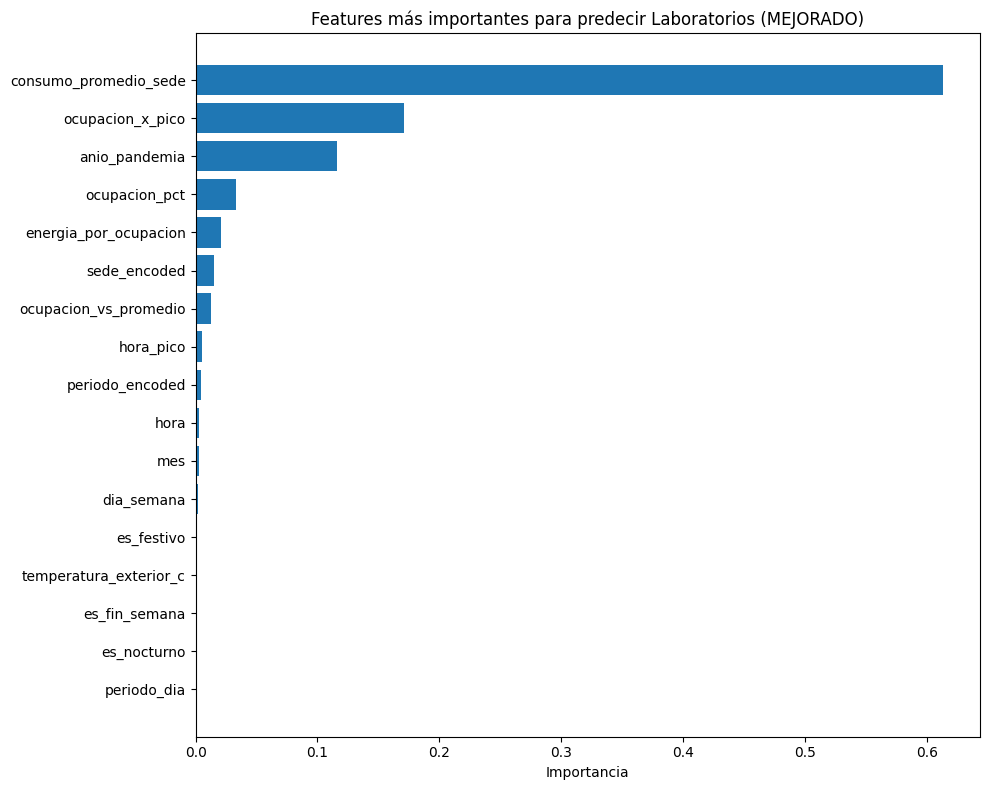

In [13]:
# Importancia de features del modelo de laboratorios
importancia = modelo_labs.feature_importances_

# Crear dataframe con NUEVA lista de features
df_importancia = pd.DataFrame({
    'feature': features_modelo,
    'importancia': importancia
}).sort_values('importancia', ascending=False)

print("IMPORTANCIA DE FEATURES (Modelo Laboratorios):")

print(df_importancia.to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['feature'], df_importancia['importancia'])
plt.xlabel('Importancia')
plt.title('Features más importantes para predecir Laboratorios (MEJORADO)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/feature_importance_v2.png', dpi=150)
print("Gráfico guardado: outputs/feature_importance_v2.png")
plt.show()


In [14]:
# Crear dataframe con predicciones
df_predicciones = datos_test[['timestamp', 'sede', 'hora', 'dia_semana']].copy()

# Agregar predicciones de cada sector
df_predicciones['comedor_pred'] = pred_comedor
df_predicciones['comedor_real'] = datos_test['energia_comedor_kwh'].values

df_predicciones['salones_pred'] = pred_salones
df_predicciones['salones_real'] = datos_test['energia_salones_kwh'].values

df_predicciones['laboratorios_pred'] = pred_labs
df_predicciones['laboratorios_real'] = datos_test['energia_laboratorios_kwh'].values

df_predicciones['auditorios_pred'] = pred_auditorios
df_predicciones['auditorios_real'] = datos_test['energia_auditorios_kwh'].values

df_predicciones['oficinas_pred'] = pred_oficinas
df_predicciones['oficinas_real'] = datos_test['energia_oficinas_kwh'].values

# Agregar total
df_predicciones['total_pred'] = prediccion_total
df_predicciones['total_real'] = datos_test['energia_total_kwh'].values

# Guardar CSV
ruta_predicciones = 'outputs/predicciones_2025.csv'
df_predicciones.to_csv(ruta_predicciones, index=False)

print(f"Predicciones guardadas: {ruta_predicciones}")
print(f"Registros guardados: {len(df_predicciones):,}")
print(f"Primeras filas:")
print(df_predicciones.head())


Predicciones guardadas: outputs/predicciones_2025.csv
Registros guardados: 28,764
Primeras filas:
                 timestamp          sede  hora  dia_semana  comedor_pred  \
243953 2025-01-01 00:00:00  Chiquinquirá     0           2      0.057888   
243954 2025-01-01 00:00:00       Duitama     0           2      0.154163   
243955 2025-01-01 00:00:00      Sogamoso     0           2      0.131675   
243956 2025-01-01 00:00:00         Tunja     0           2      0.087552   
243957 2025-01-01 01:00:00  Chiquinquirá     1           2      0.022257   

        comedor_real  salones_pred  salones_real  laboratorios_pred  \
243953        0.0590      0.157366        0.1569           0.487663   
243954        0.1795      0.388154        0.3691           2.910210   
243955        0.1803      0.332229        0.3347           2.982651   
243956        0.0000      0.157412        0.1325           1.105918   
243957        0.0605      0.172768        0.1784           0.492169   

        laboratori

In [53]:
# Verificar qué predicciones existen
print("Variables de predicción definidas:")

if 'pred_comedor' in locals():
    print(f"  pred_comedor: {len(pred_comedor)} valores")
else:
    print("  pred_comedor: NO EXISTE")

if 'pred_salones' in locals():
    print(f"  pred_salones: {len(pred_salones)} valores")
else:
    print("  pred_salones: NO EXISTE")

if 'pred_labs' in locals():
    print(f"  pred_labs: {len(pred_labs)} valores")
else:
    print("  pred_labs: NO EXISTE")

if 'pred_auditorios' in locals():
    print(f"  pred_auditorios: {len(pred_auditorios)} valores")
else:
    print("  pred_auditorios: NO EXISTE")

if 'pred_oficinas' in locals():
    print(f"  pred_oficinas: {len(pred_oficinas)} valores")
else:
    print("  pred_oficinas: NO EXISTE")


Variables de predicción definidas:
  pred_comedor: 28764 valores
  pred_salones: 28764 valores
  pred_labs: 28764 valores
  pred_auditorios: 28764 valores
  pred_oficinas: 28764 valores
